#### Naman thakkar

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import textwrap

In [2]:
sdata = pd.read_csv(r"C:\Users\Naman Thakkar\Desktop\Datasets\Space_Mission_Data_Final.csv",index_col=0)
sdata

,Organisation,Country,ISO Code,Vehicle_Name,Launch_date,Launch_Month,Launch_Year,Rocket_Status,Price,Mission_Status,Decade
0,SpaceX,USA,USA,Falcon 9 Block 5,07-08-2020,Aug,2020,StatusActive,50.00,Success,2020
1,CASC,China,CHN,Long March 2D,06-08-2020,Aug,2020,StatusActive,29.75,Success,2020
2,SpaceX,USA,USA,Starship Prototype,04-08-2020,Aug,2020,StatusActive,50.00,Success,2020
3,Roscosmos,Kazakhstan,KAZ,Proton-M/Briz-M,30-07-2020,Jul,2020,StatusActive,65.00,Success,2020
4,ULA,USA,USA,Atlas V 541,30-07-2020,Jul,2020,StatusActive,145.00,Success,2020
...,...,...,...,...,...,...,...,...,...,...,...
4319,US Navy,USA,USA,Vanguard,05-02-1958,Feb,1958,StatusRetired,62.00,Failure,1950
4320,AMBA,USA,USA,Juno I,01-02-1958,Feb,1958,StatusRetired,62.00,Success,1950
4321,US Navy,USA,USA,Vanguard,06-12-1957,Dec,1957,StatusRetired,62.00,Failure,1950
4322,RVSN USSR,Kazakhstan,KAZ,Sputnik 8K71PS,03-11-1957,Nov,1957,StatusRetired,5000.00,Success,1950


### Problem statement 1:
Identify the top 10 most frequently launched vehicles and compare their launch frequencies.

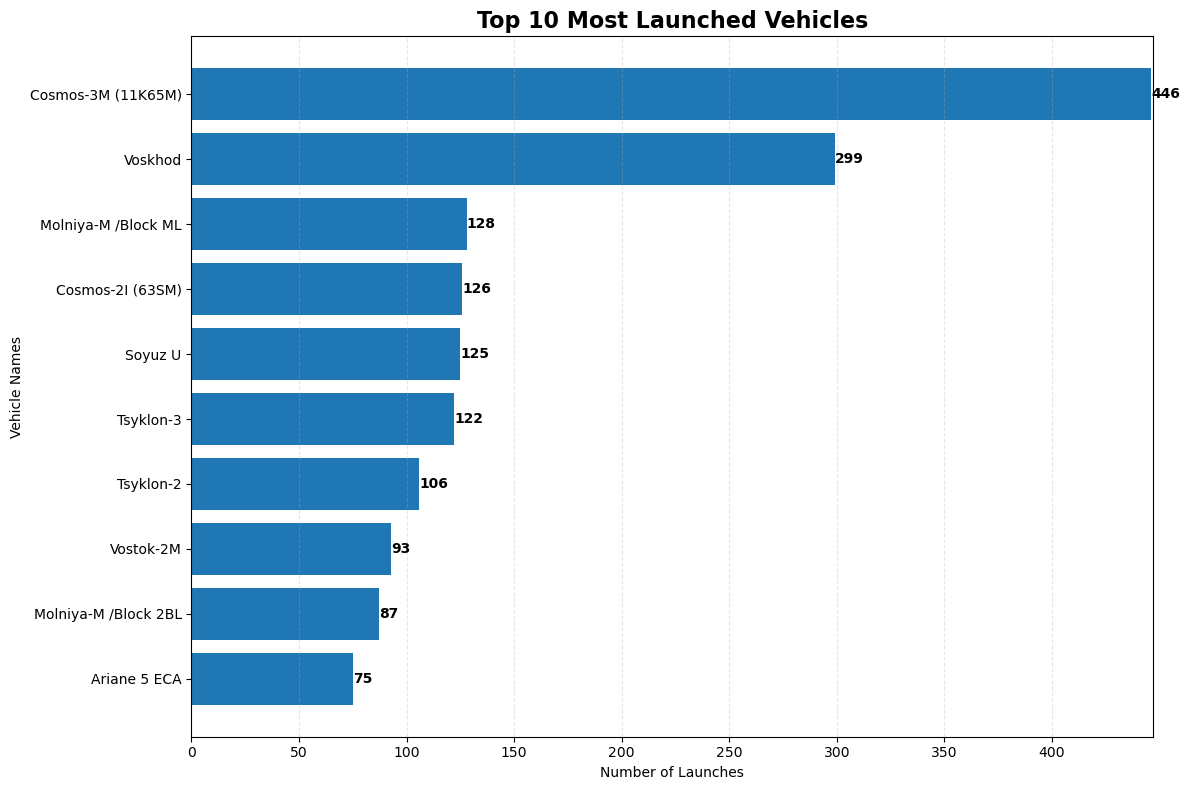

In [9]:
top10 = sdata['Vehicle_Name'].value_counts().head(10)
top10 = top10.sort_values(ascending=True)

labels = [textwrap.fill(str(x), 35) for x in top10.index]

plt.figure(figsize=(12, 8))


bars = plt.barh(labels, top10.values)

plt.title(
    'Top 10 Most Launched Vehicles',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Number of Launches')
plt.ylabel('Vehicle Names')

for bar, value in zip(bars, top10.values):
    plt.text(
        value + 0.05,
        bar.get_y() + bar.get_height()/2,
        str(value),
        va='center',
        fontweight='bold'
    )

plt.xlim(0, top10.max() + 1)
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

### Inferences
1. Cosmos-3M (11K65M) was the most frequently launched vehicle, with 446 launches, followed by Voskhod with 299 launches.
2. Cosmos-3M and Voskhod were used considerably more than the other vehicles, indicating that these rocket models were frequently selected for missions in the dataset.
3. Ariane 5 ECA had the lowest number of launches among the top 10, with 75 launches, while the remaining vehicles had between 87 and 128 launches, showing a clear difference in launch frequency.

#### Problem statement 2:
Find the Success Rate of the 15 Most-Used Rocket Models

In [5]:
# Find the 15 most-used rocket models
top10 = (
    sdata.groupby('Vehicle_Name')
    .agg(
        Total_Launches=('Mission_Status', 'size'),
        Successful_Launches=('Mission_Status',
                             lambda x: (x.str.strip().str.lower() == 'success').sum())
    )
    .sort_values('Total_Launches', ascending=False)
    .head(10)
)

# Calculate Success Rate
top10['Success_Rate'] = (
    top10['Successful_Launches'] / top10['Total_Launches']
) * 100

# Reset index
top10 = top10.reset_index()
#Display the calculated data
top10

,Vehicle_Name,Total_Launches,Successful_Launches,Success_Rate
0,Cosmos-3M (11K65M),446,419,93.946188
1,Voskhod,299,283,94.648829
2,Molniya-M /Block ML,128,122,95.312500
3,Cosmos-2I (63SM),126,118,93.650794
4,Soyuz U,125,118,94.400000
5,Tsyklon-3,122,114,93.442623
6,Tsyklon-2,106,105,99.056604
7,Vostok-2M,93,89,95.698925
8,Molniya-M /Block 2BL,87,84,96.551724
9,Ariane 5 ECA,75,73,97.333333


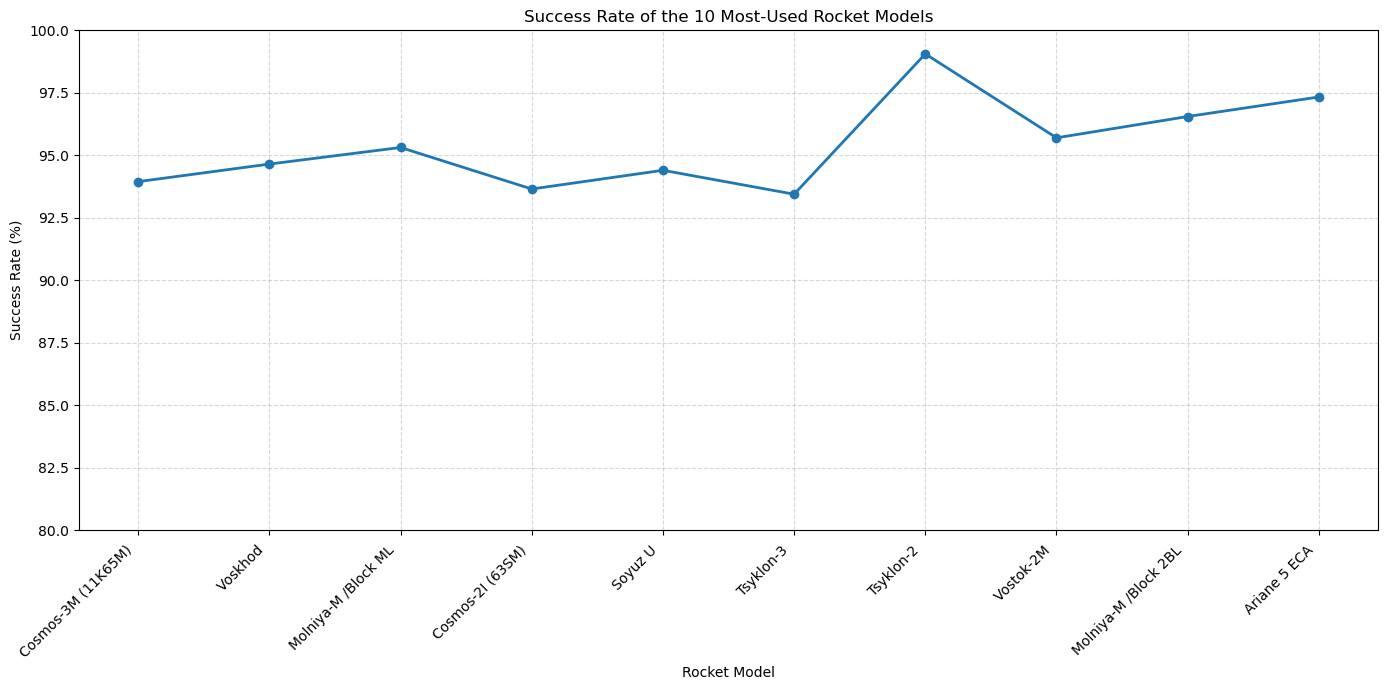

In [6]:
#Graph
plt.figure(figsize=(14, 7))

plt.plot(
    top10['Vehicle_Name'],
    top10['Success_Rate'],
    marker='o',
    linewidth=2
)

plt.title('Success Rate of the 10 Most-Used Rocket Models')
plt.xlabel('Rocket Model')
plt.ylabel('Success Rate (%)')

plt.xticks(rotation=45, ha='right')
plt.ylim(80, 100)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Inferences:
1. Tsyklon-2 has the highest success rate among the 15 most-used rocket models, with approximately 99.06%, showing very high reliability.
2. Vostok-2 has the lowest success rate, at approximately 84.44%, indicating comparatively lower reliability than the other frequently used models.
3. Most of the top 10 rocket models have success rates above 93%, showing that the frequently used rocket models in the dataset generally have a high level of launch reliability.